In [1]:
import json
import os
import numpy as np
# import torch
from collections import OrderedDict
from copy import deepcopy
import time
from droid.robot_env import RobotEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Camera, Env

action_space = "cartesian_position"
gripper_action_space = "position"


imsize = 224

camera_kwargs = dict(
    hand_camera=dict(image=True, depth=True, resolution=(1280, 720), resize_func='cv2')
)

env = RobotEnv(
    action_space=action_space,
    gripper_action_space=gripper_action_space,
    camera_kwargs=camera_kwargs
)
# env.reset(randomize=False)

Opening Zed:  14013996
14013996 hand_camera {'image': True, 'depth': True, 'resolution': (1280, 720), 'resize_func': 'cv2'}
[2026-03-19 15:01:27 UTC][ZED][INFO] Logging level INFO
[2026-03-19 15:01:27 UTC][ZED][INFO] [Init]  Depth mode: NEURAL
[2026-03-19 15:01:29 UTC][ZED][INFO] [Init]  Camera successfully opened.
[2026-03-19 15:01:29 UTC][ZED][INFO] [Init]  Camera FW version: 1523
[2026-03-19 15:01:29 UTC][ZED][INFO] [Init]  Video mode: HD720@60
[2026-03-19 15:01:29 UTC][ZED][INFO] [Init]  Serial Number: S/N 14013996
[2026-03-19 15:01:29 UTC][ZED][WARNING] [Init]  Requested depth_minimum_distance: 0.1MILLIMETER is too close, clamped to 100MILLIMETER.


In [3]:
curr_frame = env.get_observation()['image']['14013996_left']
curr_depth = env.get_observation()['depth']['14013996_left']

[2026-03-19 15:01:33 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
[2026-03-19 15:01:33 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.


NameError: name 'plt' is not defined

In [5]:
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

model = build_sam3_image_model()
processor = Sam3Processor(model)
print("SAM3 Loaded")

/home/rllab2/gwanwoo/Environment_Reset/thirdparty/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/rllab2/miniconda3/envs/anygrasp_sam3/lib/python3.10/site-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(va

SAM3 Loaded


In [7]:

curr_frame_rgb = curr_frame[...,:3][..., :: -1]

image = Image.fromarray(curr_frame_rgb)
inference_state = processor.set_image(image)
# Prompt the model with text
output = processor.set_text_prompt(state=inference_state, prompt="gold lid")

# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]



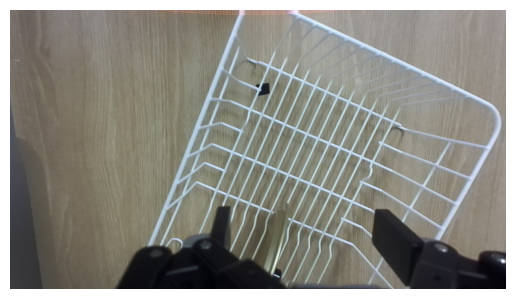

num detections: 1
scores: tensor([0.8993], device='cuda:0')
best_score: 0.8992574
best_mask shape: (720, 1280)
best_box: [472.64258 350.1782  885.72565 520.29944]
All same depth value? False


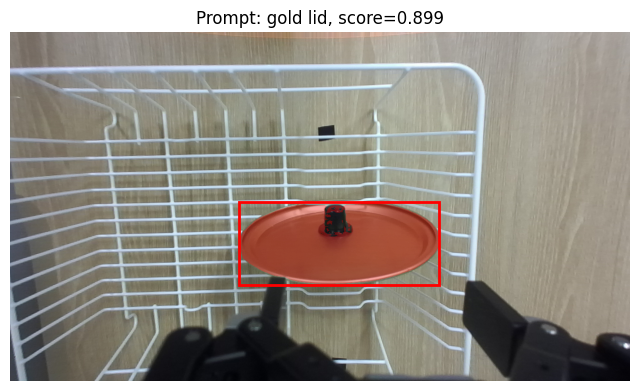

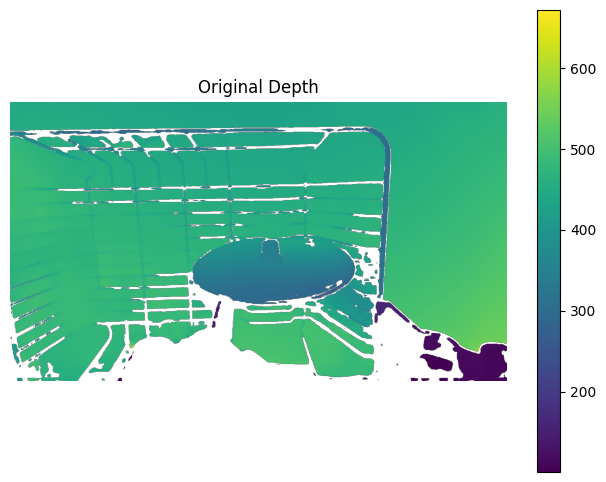

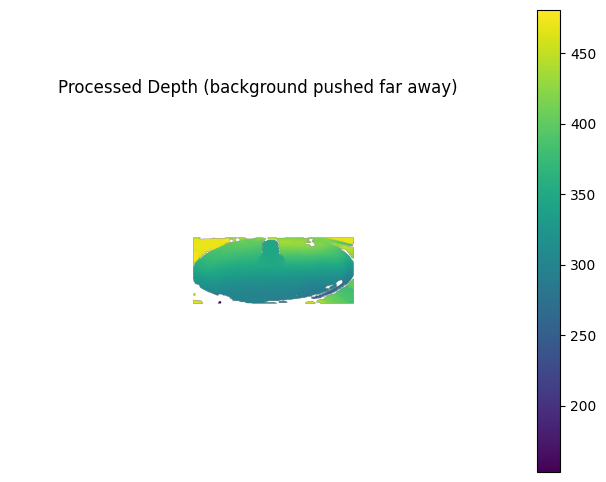

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --------------------------------------------------
# 1. SAM3 inference
# --------------------------------------------------
# curr_frame: (H, W, 4) assumed -> RGBD
curr_frame_rgb = curr_frame_rgb 
curr_depth = curr_depth

image = Image.fromarray(curr_frame_rgb.astype(np.uint8))
inference_state = processor.set_image(image)

# Replace this with your actual text prompt
text_prompt = "gold lid"   # e.g. "cup", "plate", "bowl"
output = processor.set_text_prompt(state=inference_state, prompt=text_prompt)

masks = output["masks"]
boxes = output["boxes"]
scores = output["scores"]

print("num detections:", len(scores))
print("scores:", scores)

# --------------------------------------------------
# 2. Pick the best mask
# --------------------------------------------------
# This part tries to be robust to tensor / numpy formats
def to_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.array(x)

masks_np = to_numpy(masks)
boxes_np = to_numpy(boxes)
scores_np = to_numpy(scores)

# pick best detection
best_idx = int(np.argmax(scores_np))

best_mask = masks_np[best_idx]
best_box = boxes_np[best_idx]
best_score = scores_np[best_idx]

# If mask shape is (1, H, W), squeeze it
if best_mask.ndim == 3 and best_mask.shape[0] == 1:
    best_mask = best_mask[0]

# convert to boolean mask
# if SAM3 returns logits/probabilities, threshold at 0.5
if best_mask.dtype != np.bool_:
    best_mask = best_mask > 0.5

print("best_score:", best_score)
print("best_mask shape:", best_mask.shape)
print("best_box:", best_box)

# --------------------------------------------------
# 3. Make background depth much larger
# --------------------------------------------------
# Option A: set background depth to a constant large value
processed_depth = curr_depth.copy()

# All depth same?
print ("All same depth value?", np.all(curr_depth == curr_depth[0,0]))


x1,y1,x2,y2 = best_box[:4].astype(int)
box_mask = np.zeros(curr_depth.shape[:2], dtype=bool)
box_mask [y1:y2, x1:x2] = True

large_depth_value = curr_depth.max() + 1000  # adjust depending on your depth scale
processed_depth[~box_mask] = large_depth_value

# If you want only one object and all else far away:
processed_curr_frame = curr_frame.copy()
processed_curr_frame[..., :3] = curr_frame_rgb
processed_curr_frame[..., 3] = processed_depth

# --------------------------------------------------
# 4. Visualization helpers
# --------------------------------------------------
def visualize_bbox_and_mask(rgb, box, mask, title="Detection"):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(rgb)

    # bbox format is usually [x1, y1, x2, y2]
    x1, y1, x2, y2 = box[:4]
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    # overlay mask
    mask_overlay = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.float32)
    mask_overlay[..., 0] = 1.0   # red
    mask_overlay[..., 3] = mask.astype(np.float32) * 0.35
    ax.imshow(mask_overlay)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

def visualize_depth(depth, title="Depth"):
    plt.figure(figsize=(8, 6))
    plt.imshow(depth, cmap="viridis")
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()

# --------------------------------------------------
# 5. Show results
# --------------------------------------------------
visualize_bbox_and_mask(
    curr_frame_rgb,
    best_box,
    best_mask,
    title=f"Prompt: {text_prompt}, score={best_score:.3f}"
)



visualize_depth(curr_depth, title="Original Depth")
visualize_depth(processed_depth, title="Processed Depth (background pushed far away)")






In [13]:
def run(env, pose6, duration=1.0, grip_close=False, hz=15):
    """
        pose6: [x,y,z,rx,ry,rz]
        grip_close: True==Close / False==Open
    """
    pose= np.array(pose6, dtype=np.float32)
    grip= np.array([1.0 if grip_close else 0.0], dtype=np.float32)
    action= np.concatenate([pose, grip], axis=0)

    for _ in range(int(duration * hz)):
        env.step(action)
        time.sleep(1.0 / hz)

top_pose = [0.4350,
0.0,
0.75,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
# bottom_pose = [0.4321105480194092,
#  0,
#  0.150000000000000,
#  -3.141084945536129,
#  0.022017310521937228,
#  -0.01628570321540242]
bottom_pose = [0.4350,
0.0,
0.19,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
home_pose = [   0.4350, # x
                0.0,    # y
                0.4,    # z
                -3.135387735082638, # roll - rotation around x-axis
                # -3.135387735082638, # roll - rotation around x-axis
                0.0117385168564208, # pitch - rotation around y-axis
                -0.008736370437155985] # yaw - rotation around z-axis

In [14]:
run(env, top_pose, 1, False, 15)

In [15]:
import cv2
import numpy as np
from scipy.spatial.transform import Rotation # Added for robust Euler conversion

def xyzrpy_to_matrix(pose_6d):
    """
    Converts a 6D pose [x, y, z, roll, pitch, yaw] into a 4x4 transformation matrix.
    Assumes rx, ry, rz are in radians and follow the extrinsic 'xyz' convention.
    """
    x, y, z, rx, ry, rz = pose_6d
    
    # Convert Euler angles to 3x3 rotation matrix
    # Note: 'xyz' is standard roll-pitch-yaw. Change to 'zyx' if your robot uses Z-Y-X intrinsic.
    R_mat = Rotation.from_euler('xyz', [rx, ry, rz], degrees=False).as_matrix()
    
    # Build 4x4 matrix
    T = np.eye(4)
    T[:3, :3] = R_mat
    T[:3, 3] = [x, y, z]
    
    return T

def perform_hand_eye_calibration(env, num_poses=15, marker_length=0.099):
    # 1. Define Camera Intrinsics
    camera_matrix = np.array([
        [732.277771, 0.0, 614.49353027],
        [0.0, 732.277771, 352.48422241],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)
    dist_coeffs = np.zeros((4, 1)) 

    # 2. Setup ArUco Dictionary and Parameters
    # 2. Setup ArUco Dictionary and Parameters safely
    cv_major_version = int(cv2.__version__.split('.')[0])
    cv_minor_version = int(cv2.__version__.split('.')[1])
    
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    
    if cv_major_version >= 4 and cv_minor_version >= 7:
        # Modern OpenCV (4.7+)
        aruco_params = cv2.aruco.DetectorParameters()
        detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)
    else:
        # Legacy OpenCV (< 4.7)
        # Note: older versions sometimes required DetectorParameters_create()
        try:
            aruco_params = cv2.aruco.DetectorParameters_create()
        except AttributeError:
            aruco_params = cv2.aruco.DetectorParameters()
    
    # Storage for calibration
    R_gripper2base = []
    t_gripper2base = []
    R_target2cam = []
    t_target2cam = []

    poses_collected = 0

    print(f"Starting data collection. Need {num_poses} valid poses...")

    while poses_collected < num_poses:
        # Base pose
        top_pose = [
            0.4350,
            0.0,
            0.75,
            -3.135387735082638,
            0.0117385168564208,
            -0.008736370437155985
        ]
        
        # Fixed: Adjusted the last index of low/high so low < high
        low = np.array([-0.2, -0.2, -0.2, -0.314/2, -0.314/2, -0.314/2]) 
        high = np.array([ 0.2,  0.2,  0.0,  0.314/2,  0.314/2,  0.314/2])

        # Sample a single 6D vector and add to base pose
        sample = np.random.uniform(low=low, high=high)
        pose_6d = np.array(top_pose) + sample
        
        
        # Move the robot using the 6D pose
        run(env, pose_6d, 5, False, 15)
        # time.sleep(2)
        
        # --> NEW: Convert the 6D pose to a 4x4 matrix <--
        T_base_to_eef = xyzrpy_to_matrix(pose_6d)
        

        # Get the image
        obs = env.get_observation()
        img = obs['image']['14013996_left'][..., :3]
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # return None
        # Detect ArUco marker safely based on version
        if cv_major_version >= 4 and cv_minor_version >= 7:
            corners, ids, rejected = detector.detectMarkers(gray)
        else:
            corners, ids, rejected = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
        
        # return None
        if ids is not None and len(ids) > 0:
            print('aruco detected')
            # Estimate pose of the marker
            rvecs, tvecs, _ = cv2.aruco.estimatePoseSingleMarkers(
                corners, marker_length, camera_matrix, dist_coeffs
            )
            
            # Use the first detected marker
            rvec = rvecs[0][0]
            tvec = tvecs[0][0]

            # Convert rvec to 3x3 rotation matrix for the camera-to-marker
            R_cam, _ = cv2.Rodrigues(rvec)
            
            # Store ArUco pose relative to camera
            R_target2cam.append(R_cam)
            t_target2cam.append(tvec.reshape(3, 1))

            # Extract Robot EEF rotation and translation
            # Now T_base_to_eef is properly formatted as a 4x4 matrix
            R_eef = T_base_to_eef[:3, :3]
            t_eef = T_base_to_eef[:3, 3].reshape(3, 1)
            
            R_gripper2base.append(R_eef)
            t_gripper2base.append(t_eef)

            poses_collected += 1
            print(f"Collected pose {poses_collected}/{num_poses}")
        else:
            print("ArUco marker not visible. Resampling pose...")
            continue

    print("Data collection complete. Running calibration...")

    # 3. Compute Hand-Eye Calibration
    R_cam2gripper, t_cam2gripper = cv2.calibrateHandEye(
        R_gripper2base, t_gripper2base, 
        R_target2cam, t_target2cam,
        method=cv2.CALIB_HAND_EYE_TSAI
    )

    # Construct the 4x4 transformation matrix: T_eef_to_cam
    T_eef_to_cam = np.eye(4)
    T_eef_to_cam[:3, :3] = R_cam2gripper
    T_eef_to_cam[:3, 3] = t_cam2gripper.flatten()

    return T_eef_to_cam

In [16]:
T_eef_to_cam = perform_hand_eye_calibration(env, num_poses=30, marker_length=0.099)

Starting data collection. Need 30 valid poses...
[2026-02-24 11:19:28 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
aruco detected
Collected pose 1/30
[2026-02-24 11:19:34 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
ArUco marker not visible. Resampling pose...
[2026-02-24 11:19:39 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
aruco detected
Collected pose 2/30
[2026-02-24 11:19:45 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
ArUco marker not visible. Resampling pose...
[2026-02-24 11:19:50 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
aruco detected
Collected pose 3/30
[2026-02-24 11:19:56 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitPara

In [17]:
print("Static Transform (EEF to Camera):\n", T_eef_to_cam)

Static Transform (EEF to Camera):
 [[ 0.02946096  0.96602136  0.25677771 -0.02588738]
 [-0.9994151   0.03293049 -0.00922131  0.0238128 ]
 [-0.0173638  -0.25635585  0.9664265   0.02904815]
 [ 0.          0.          0.          1.        ]]


In [3]:
import numpy as np
g_T_c = np.array(
[[ 0.0504003,   0.95970796,  0.27644248, -0.05503207],
 [-0.99865687,  0.0517565,   0.00239283,  0.03024105],
 [-0.01201128, -0.27619178,  0.96102749,  0.0244508 ],
 [ 0.,          0.,          0.,          1.,        ]]
)

In [4]:
obs = env.get_observation()
obs.keys()


dict_keys(['timestamp', 'robot_state', 'camera_type', 'camera_extrinsics', 'camera_intrinsics'])

In [16]:
run(env, home_pose, duration=1, grip_close=1)

In [6]:
obs = env.get_observation()
obs.keys()
obs["camera_intrinsics"]
print(obs["camera_intrinsics"])

# {'14013996_left': array([[732.277771  ,   0.        , 614.49353027],
#         [  0.        , 732.277771  , 352.48422241],
#         [  0.        ,   0.        ,   1.        ]]),

fx = 732.277771
fy = 732.277771
cx = 614.49353027
cy = 352.48422241

{}


In [14]:
cam_key = list(obs["image"].keys())[0]
print("Using cam_key:", cam_key)

print("intrinsic exists:", cam_key in obs["camera_intrinsics"])
print("extrinsic exists:", cam_key in obs["camera_extrinsics"])
print("depth exists:", cam_key in obs["depth"])

Using cam_key: 14013996_left
intrinsic exists: True
extrinsic exists: False
depth exists: True


In [7]:
# AnyGrasp setup

from gsnet import AnyGrasp
from graspnetAPI import GraspGroup




checking license on /home/rllab2/gwanwoo/Environment_Reset/gsnet.so
license passed: True, state: FvrLicenseState.PASSED
[2026-02-23 19:22:27.594] [info] [FlexivLic] public key GwanwooSong.public_key & signature GwanwooSong.signature are matched
[2026-02-23 19:22:27.594] [info] [FlexivLic] license /home/rllab2/gwanwoo/Environment_Reset/license/GwanwooSong.lic check passed.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/rllab2/miniconda3/envs/anygrasp_droid/lib/python3.10/site-packages/MinkowskiEngine-0.5.4-py3.10-linux-x86_64.egg/MinkowskiEngine/__init__.py:36: UserWarning: The environment variable `OMP_NUM_THREADS` not set. MinkowskiEngine will automatically set `OMP_NUM_THREADS=16`. If you want to set `OMP_NUM_THREADS` manually, please export it on the command line before running a python script. e.g. `export OMP_NUM_THREADS=12; python your_program.py`. It is recommended to set it below 24.
  warnings.warn(


In [9]:
import os
import argparse
import torch
import numpy as np
import open3d as o3d
from PIL import Image

from gsnet import AnyGrasp
from graspnetAPI import GraspGroup

parser = argparse.ArgumentParser()
parser.add_argument('--checkpoint_path', default="log/checkpoint_detection.tar", help='Model checkpoint path')
parser.add_argument('--max_gripper_width', type=float, default=0.1, help='Maximum gripper width (<=0.1m)')
parser.add_argument('--gripper_height', type=float, default=0.03, help='Gripper height')
parser.add_argument('--top_down_grasp', default=True, type=bool, help='Output top-down grasps.')
parser.add_argument('--debug', action='store_true', help='Enable debug mode')
cfgs = parser.parse_args()
cfgs.max_gripper_width = max(0, min(0.1, cfgs.max_gripper_width))

def demo():
    anygrasp = AnyGrasp(cfgs)
    anygrasp.load_net()

    # get data
    # colors = np.array(Image.open(os.path.join(data_dir, 'color.png')), dtype=np.float32) / 255.0
    # depths = np.array(Image.open(os.path.join(data_dir, 'depth.png')))
    obs = env.get_observation()
    colors = obs['image']['14013996_left']
    depths = obs['depth']['14013996_left']
    
    # get camera intrinsics
    fx, fy = fx, fy     # NOTE: needs to be changed 
    cx, cy = cx, cy     # NOTE: needs to be changed 
    scale = 1000.0              # NOTE: needs to be changed 
    # set workspace to filter output grasps
    xmin, xmax = -0.19, 0.12
    ymin, ymax = 0.02, 0.15
    zmin, zmax = 0.0, 1.0
    lims = [xmin, xmax, ymin, ymax, zmin, zmax]

    # get point cloud
    xmap, ymap = np.arange(depths.shape[1]), np.arange(depths.shape[0])
    xmap, ymap = np.meshgrid(xmap, ymap)
    points_z = depths / scale
    points_x = (xmap - cx) / fx * points_z
    points_y = (ymap - cy) / fy * points_z

    # set your workspace to crop point cloud
    mask = (points_z > 0) & (points_z < 1)
    points = np.stack([points_x, points_y, points_z], axis=-1)
    points = points[mask].astype(np.float32)
    colors = colors[mask].astype(np.float32)
    print(points.min(axis=0), points.max(axis=0))

    gg, cloud = anygrasp.get_grasp(points, colors, lims=lims, apply_object_mask=True, dense_grasp=False, collision_detection=True)

    if len(gg) == 0:
        print('No Grasp detected after collision detection!')

    gg = gg.nms().sort_by_score()
    gg_pick = gg[0:20]
    print(gg_pick.scores)
    print('grasp score:', gg_pick[0].score)

    # visualization
    if cfgs.debug:
        trans_mat = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],[0,0,0,1]])
        cloud.transform(trans_mat)
        grippers = gg.to_open3d_geometry_list()
        for gripper in grippers:
            gripper.transform(trans_mat)
        o3d.visualization.draw_geometries([*grippers, cloud])
        o3d.visualization.draw_geometries([grippers[0], cloud])


    
demo()
# demo('./example_data/')


# python demo.py --checkpoint_path log/checkpoint_detection.tar --top_down_grasp

usage: ipykernel_launcher.py [-h] [--checkpoint_path CHECKPOINT_PATH]
                             [--max_gripper_width MAX_GRIPPER_WIDTH]
                             [--gripper_height GRIPPER_HEIGHT]
                             [--top_down_grasp TOP_DOWN_GRASP] [--debug]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1000/jupyter/runtime/kernel-v3270695ca28dab31fda9474b798f56eea14e9e543.json


SystemExit: 2

In [30]:
import os
import torch
import numpy as np
from PIL import Image
from gsnet import AnyGrasp

class Cfg: pass
cfgs = Cfg()
cfgs.checkpoint_path = "log/checkpoint_detection.tar"
cfgs.max_gripper_width = 0.1
cfgs.gripper_height = 0.03
cfgs.top_down_grasp = True
cfgs.debug = False
cfgs.max_gripper_width = max(0, min(0.1, cfgs.max_gripper_width))

def demo():
    anygrasp = AnyGrasp(cfgs)
    anygrasp.load_net()

    # colors = np.array(Image.open(os.path.join(data_dir, 'color.png')), dtype=np.float32) / 255.0
    # depth_img = Image.open(os.path.join(data_dir, 'depth.png'))
    # depths = np.array(depth_img)

    obs = env.get_observation()
    colors = obs['image']['14013996_left']
    depths = obs['depth']['14013996_left']
    print(colors.shape, depths.shape)

    # print("depth mode:", depth_img.mode, "dtype:", depths.dtype, "min/max:", depths.min(), depths.max())

    # TODO: replace with your camera intrinsics
    fx = 732.277771
    fy = 732.277771
    cx = 614.49353027
    cy = 352.48422241
    scale = 1000.0  # mm->m

    lims = [-0.5, 0.5, -0.5, 0.5, 0.02, 1.5]

    xmap, ymap = np.meshgrid(np.arange(depths.shape[1]), np.arange(depths.shape[0]))
    points_z = depths.astype(np.float32) / scale
    points_x = (xmap - cx) / fx * points_z
    points_y = (ymap - cy) / fy * points_z

    mask = (points_z > 0.02) & (points_z < 1.5) & np.isfinite(points_z)
    points = np.stack([points_x, points_y, points_z], axis=-1)[mask].astype(np.float32)
    cols = colors[mask].astype(np.float32)

    print("points range:", points.min(axis=0), points.max(axis=0), "N:", len(points))

    gg, cloud = anygrasp.get_grasp(points, cols, lims=lims,
                                   apply_object_mask=True, dense_grasp=False, collision_detection=True)

    if len(gg) == 0:
        print("No grasp detected.")
        return None

    gg = gg.nms().sort_by_score()
    print("top score:", gg[0].score)
    return gg

gg = demo()
print(gg.translations)
print(type(gg))

[2026-02-23 10:38:56 UTC][ZED][ERROR] [ZED] Measure not available, you should activate 'InitParameters::enable_right_side_measure'.
(720, 1280, 4) (720, 1280)
points range: [-0.52086    -0.26234645  0.09988035] [0.5995629  0.27650934 0.747218  ] N: 732985
top score: 0.4774082899093628
[[-8.17748979e-02  3.89386266e-02  5.45007348e-01]
 [-3.46402638e-02 -7.44404793e-02  5.21628499e-01]
 [-8.24367702e-02  3.63453329e-02  5.44351161e-01]
 [-8.01255628e-02  3.86915281e-02  5.44685423e-01]
 [-7.26342425e-02  1.59035437e-02  5.47704935e-01]
 [-9.01830867e-02  3.29628289e-02  5.45117736e-01]
 [-3.06526516e-02 -7.90046602e-02  5.22203982e-01]
 [-6.71031997e-02  3.91602442e-02  5.45974314e-01]
 [-3.69163528e-02 -7.27974325e-02  5.22577405e-01]
 [-3.23942266e-02 -7.72558823e-02  5.23275614e-01]
 [-6.02572225e-02  2.86819562e-02  5.44253767e-01]
 [-3.46211120e-02 -6.95707351e-02  5.22311270e-01]
 [-3.25094908e-02 -7.39989281e-02  5.25397062e-01]
 [-7.59713203e-02  3.01816743e-02  5.43249667e-01]


In [ ]:
obs['robot_state'].keys()

dict_keys(['cartesian_position', 'gripper_position', 'joint_positions', 'joint_velocities', 'joint_torques_computed', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened', 'motor_torques_measured', 'prev_controller_latency_ms', 'prev_command_successful'])

In [ ]:
obs['image'].keys()


dict_keys(['36776608_left', '36776608_right'])

In [ ]:
obs['image'].keys()
obs['image']['36776608_left'].shape
obs["camera_intrinsics"]

{'36776608_left': array([[520.20617676,   0.        , 635.42834473],
        [  0.        , 520.20617676, 362.10696411],
        [  0.        ,   0.        ,   1.        ]]),
 '36776608_right': array([[520.20617676,   0.        , 635.42834473],
        [  0.        , 520.20617676, 362.10696411],
        [  0.        ,   0.        ,   1.        ]])}

In [ ]:
obs['image']['36776608_left'].shape
arr = obs['image']['36776608_left']
print("min/max per channel:", [ (arr[...,c].min(), arr[...,c].max()) for c in range(arr.shape[-1])])

a = arr[..., 3]
print("A mean/std:", float(a.mean()) , float(a.std()))

min/max per channel: [(0, 255), (0, 255), (0, 255), (255, 255)]
A mean/std: 255.0 0.0


(224, 224, 4)


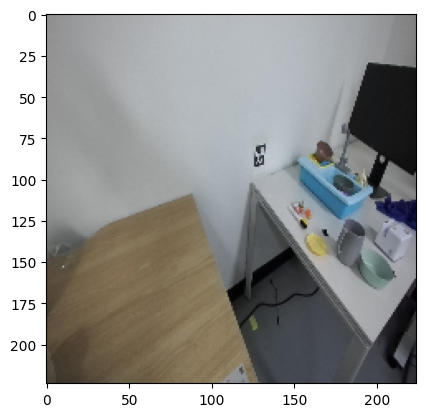

In [ ]:
obs['image']['14013996_left'].shape, type(obs['image']['14013996_left']), obs['image']['14013996_left'].dtype
import matplotlib.pyplot as plt 
print(obs['image']['36776608_left'].shape) # BGRA (H, W, 4)
plt.imshow(obs['image']['36776608_left'][..., :3][ :, :,::-1]) # BGRA -> BGR -> RGB
# .keys()
# from PIL import Image 
# img = Image.fromarray(obs['image']['36776608_left'])
# img.save("test.jpg", format="bgr")

In [ ]:
def run(env, pose, duration=1.0, grp=False):
    pose = np.array(pose)
    pose = np.concatenate([pose, np.array([1.0]) if grp else np.array([0.0])])
    for i in range(int(duration * 15)):
        env.step(pose)
        time.sleep(1/15)

In [ ]:
def dry_run(env, pose, grp=False):
    pose = np.array(pose)
    pose = np.concatenate([pose, np.array([1.0]) if grp else np.array([0.0])])
    env.step(pose)
    time.sleep(1/30)

In [ ]:
top_pose = [0.4350,
0.0,
0.75,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
# bottom_pose = [0.4321105480194092,
#  0,
#  0.150000000000000,
#  -3.141084945536129,
#  0.022017310521937228,
#  -0.01628570321540242]
bottom_pose = [0.4350,
0.0,
0.19,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
home_pose = [   0.4350, # x
                0.0,    # y
                0.4,    # z
                -3.135387735082638, # roll - rotation around x-axis
                # -3.135387735082638, # roll - rotation around x-axis
                0.0117385168564208, # pitch - rotation around y-axis
                -0.008736370437155985] # yaw - rotation around z-axis

In [ ]:
top_pose = [0.4350,
0.0,
0.75,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
# bottom_pose = [0.4321105480194092,
#  0,
#  0.150000000000000,
#  -3.141084945536129,
#  0.022017310521937228,
#  -0.01628570321540242]
bottom_pose = [0.4350,
0.0,
0.19,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]
home_pose = [   0.4350, # x
                0.0,    # y
                0.4,  # z
                -3.135387735082638, # roll - rotation around x-axis
                # -3.135387735082638, # roll - rotation around x-axis
                0.0117385168564208, # pitch - rotation around y-axis
                -0.008736370437155985] # yaw - rotation around z-axis
run(env, home_pose, duration=2.0, grp=False)

NameError: name 'env' is not defined

In [ ]:
run(env, bottom_pose, duration=2.0, grp=True)

In [ ]:
run(env, home_pose, duration=2.0, grp=True)

In [ ]:
run(env, home_pose, duration=2.0, grp=False)

In [ ]:
resolution = 40
radius = 0.10

home_pose= [   0.4350, # x
                0.0,    # y
                0.4,  # z
                -3.135387735082638, # roll - rotation around x-axis
                # -3.135387735082638, # roll - rotation around x-axis
                0.0117385168564208, # pitch - rotation around y-axis
                -0.008736370437155985]

circle_start_pose = [0.4350 - radius,
0.0,
0.4,
-3.135387735082638,
0.0117385168564208 + np.pi/6,
-0.008736370437155985]

run(env, circle_start_pose, duration=2.0, grp=True)

for i in range(resolution):
    if i < resolution / 2:
        circle_current_pose = [0.4350 - radius * np.cos(2*np.pi / resolution * i),
            0.0,
            0.4 - radius * np.sin(2*np.pi / resolution * i),
            -3.135387735082638,
            0.0117385168564208 + np.pi/6 - (np.pi/2.5+np.pi/6) * i / (resolution / 2),
            -0.008736370437155985
        ]
        dry_run(env, circle_current_pose, grp=True)
    elif i < resolution * 3 / 4 :
        circle_current_pose = [0.4350 - radius * np.cos(2*np.pi / resolution * i),
            0.0,
            0.4 - radius * np.sin(2*np.pi / resolution * i),
            -3.135387735082638,
            0.0117385168564208 - (np.pi/2.5),
            -0.008736370437155985
        ]
        dry_run(env, circle_current_pose, grp=True)
    else:
        circle_current_pose = [0.4350 - radius * np.cos(2*np.pi / resolution * i),
            0.0,
            0.4 - radius * np.sin(2*np.pi / resolution * i),
            -3.135387735082638,
            0.0117385168564208 - (np.pi/2.5) * (resolution - i) / (resolution / 4),
            -0.008736370437155985
        ]
        dry_run(env, circle_current_pose, grp=False)

circle_end_pose = [0.4350 - radius,
0.0,
0.4,
-3.135387735082638,
0.0117385168564208,
-0.008736370437155985]

run(env, circle_end_pose, grp=False)


In [ ]:
home_pose= [   0.4350, # x
                0.0,    # y
                0.4,  # z
                -3.135387735082638, # roll - rotation around x-axis
                # -3.135387735082638, # roll - rotation around x-axis
                0.0117385168564208, # pitch - rotation around y-axis
                -0.008736370437155985]

# Circle + Twist  (Recap)


def circle_xz_plan (i, resolution, radius, center_x=home_pose[0], center_y=home_pose[1], center_z=home_pose[2]):
    theta = 2 * np.pi * i / reslution 
    x = center_x - radiux * np.cos(data)
    y = center_y
    z = center_z - radius * np.sin(theta)
    return x,y,z 

def lerp (a,b,t):
    """Linear interpolation"""
    if end==start:


In [ ]:
for j in range(10):
    if j % 2 == 0:
        shake_pose = [0.4350+0.1,
        0.0+0.1,
        0.6,
        -3.135387735082638 + 0.3,
        0.0117385168564208 - 0.3,
        -0.008736370437155985]
    else:
        shake_pose = [0.4350-0.1,
        0.0-0.1,
        0.6,
        -3.135387735082638 - 0.3,
        0.0117385168564208 + 0.3,
        -0.008736370437155985]

    run(env, shake_pose, duration=0.5, grp=True)

In [ ]:
obs_dict = env.get_observation()
obs_dict.keys()

dict_keys(['timestamp', 'robot_state', 'image', 'camera_type', 'camera_extrinsics', 'camera_intrinsics'])

In [ ]:
type(obs_dict["image"])
obs_dict["image"]["14013996_left"]
print(obs_dict["image"]["14013996_left"].shape)
img = obs_dict["image"]["14013996_left"][..., :3]
from PIL import Image
img_pil = Image.fromarray(img)
img_pil.show()

(720, 1280, 4)


In [ ]:
def environment_reset(env):
    
    ## somehow decide 

In [ ]:
run(env, top_pose, duration=2.0, grp=False)
run(env, bottom_pose, duration=2.0, grp=False)
run(env, bottom_pose, duration=1.0, grp=True)
run(env, top_pose, duration=2.0, grp=True)

x_offset = 0.1
new_top_pose = top_pose + np.array([x_offset, 0, -0.1, 0, 0, 0])
new_bottom_pose = bottom_pose + np.array([x_offset, 0, 0, 0, 0, 0])
run(env, new_top_pose, duration=1.0, grp=True)
run(env, new_bottom_pose, duration=1.0, grp=True)

In [ ]:
env.reset()

In [ ]:
file['action'].keys()

<KeysViewHDF5 ['cartesian_position', 'cartesian_velocity', 'gripper_position', 'gripper_velocity', 'joint_position', 'joint_velocity', 'robot_state', 'target_cartesian_position', 'target_gripper_position']>

Keys in the file: ['action', 'observation']
action: <KeysViewHDF5 ['cartesian_position', 'cartesian_velocity', 'gripper_position', 'gripper_velocity', 'joint_position', 'joint_velocity', 'robot_state', 'target_cartesian_position', 'target_gripper_position']>
observation: <KeysViewHDF5 ['camera_extrinsics', 'camera_intrinsics', 'camera_type', 'controller_info', 'image', 'robot_state', 'timestamp']>
observation/robot_state [ 3.69359612e-01 -2.30292440e-03  4.84423012e-01  3.13071729e+00
  7.92915923e-03  2.12988623e-02]
<KeysViewHDF5 ['14013996_left', '14013996_right', '36776608_left', '36776608_right']>
camera extrinsics <KeysViewHDF5 ['19824535_left', '19824535_right', '23404442_left', '23404442_right', '26405488_left', '26405488_right', '29838012_left', '29838012_right']>
<KeysViewHDF5 ['cameras', 'control', 'robot_state', 'skip_action']>
<KeysViewHDF5 ['14013996_estimated_capture', '14013996_frame_received', '14013996_read_end', '14013996_read_start', '36776608_estimated_capture', '3

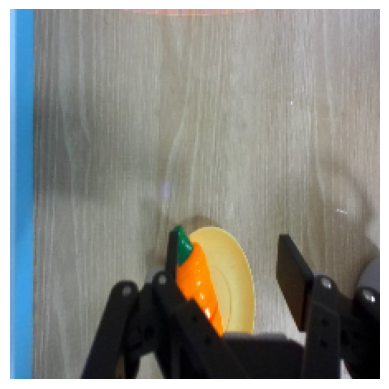

In [ ]:
import h5py
import matplotlib.pyplot as plt 
import os 

# num_demos = len(os.listdir("/media/rllab/d02b4534-6026-4063-b882-c85585c5a0bf/1859138586/close_the_trash_bin"))
# # num_demos = len(os.listdir("/home/rllab/droid/data/success/1859138586/pick_the_blue_towel_and_place_it_in_the_bowl"))
# print(num_demos)

filepath = f"/home/rllab2/jellyho/Environment_Reset/droid/data/2026-01-15/pick_carrot/success/trajectory_7.h5"
# filepath = f"/home/rllab2/droid/data/success/1859138586/pick_the_blue_towel_and_place_it_in_the_bowl/{demo_id}/trajectory.h5"

# Open the HDF5 file
file = h5py.File(filepath, 'r')
# print(demo_id)
print("Keys in the file:", list(file.keys()))
print("action:", file["action"].keys())
print("observation:", file["observation"].keys())
print("observation/robot_state", file["observation"]["robot_state"]["cartesian_position"][0])
print(file["observation/image"].keys())
print("camera extrinsics", file["observation/camera_extrinsics"].keys())
ts = file["observation/timestamp"]

# print(ts['skip_action'][:])
print(ts.keys())
print(ts["cameras"].keys())

# print(ts["cameras/32492097_read_start"].shape)
# print(ts["cameras/32492097_read_end"].shape, type(ts["cameras/32492097_read_end"]))

# print("robot_state", file["observation"]["robot_state"].keys())

print("wrist cam shape" ,file["observation/image/14013996_left"].shape)
# print(file["observation/image/32492097_left"].shape)
print(len(file["observation/image/14013996_left"]))
sample_image = file["observation/image/14013996_left"][~ts['skip_action'][:]][-1]
sh = file["observation/image/14013996_left"][0].shape
print("shape", sh)
sample_image = sample_image[:, :, [2, 1, 0]] # BGR -> RGB


plt.imshow(sample_image)
plt.axis("off")
plt.show()

In [ ]:
import h5py
import cv2
import numpy as np
import os
import argparse

def h5_to_video(h5_path, output_dir, fps=30):
    """
    Reads an HDF5 file and converts image datasets into MP4 videos.
    Assumes structure: observations/images/<camera_name>
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    filename = os.path.basename(h5_path).split('.')[0]
    
    with h5py.File(h5_path, 'r') as f:
        # 1. Locate the images group
        # Modify this path if your structure is different (e.g. just "images")
        if "observation/image" in f:
            image_group = f["observation/image"]
        elif "image" in f:
            image_group = f["image"]
        else:
            print(f"Could not find 'images' group in {h5_path}. Keys: {list(f.keys())}")
            return

        # 2. Iterate over each camera found in the file
        for cam_name in image_group.keys():
            print(f"Processing camera: {cam_name}...")
            dataset = image_group[cam_name]
            
            # 3. Determine Data Type (Raw Array vs Compressed Bytes)
            is_compressed = (dataset.ndim == 1) # 1D array usually means byte strings
            num_frames = len(dataset)
            
            # Setup Video Writer
            video_name = f"{filename}_{cam_name}.mp4"
            save_path = os.path.join(output_dir, video_name)
            
            writer = None

            for i in range(num_frames):
                data = dataset[i]

                if is_compressed:
                    # Case A: Decoding JPEG bytes
                    # np.frombuffer is faster than np.fromstring
                    arr = np.frombuffer(data, dtype=np.uint8)
                    frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                else:
                    # Case B: Raw Numpy Array (T, H, W, C)
                    frame = data
                    # OpenCV expects BGR, but usually ML datasets are RGB.
                    # Flip if necessary.
                    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                    # print(frame.shape)

                if frame is None:
                    continue

                # Initialize Writer once we know the frame size
                if writer is None:
                    height, width = frame.shape[:2]
                    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # or 'avc1' for h264
                    writer = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

                writer.write(frame)

            if writer:
                writer.release()
            print(f"Saved: {save_path}")


# h5_to_video('/home/rllab2/jellyho/Environment_Reset/droid/data/2026-01-15/pick_carrot/success/trajectory_7.h5', '.', 10)
h5_to_video('/home/rllab2/jellyho/Environment_Reset/droid/data/2026-01-21/refill_tape/success/trajectory_29.h5', '.', 10)

Processing camera: 14013996_left...
Saved: ./trajectory_29_14013996_left.mp4
Processing camera: 14013996_right...
Saved: ./trajectory_29_14013996_right.mp4
Processing camera: 36776608_left...
Saved: ./trajectory_29_36776608_left.mp4
Processing camera: 36776608_right...
Saved: ./trajectory_29_36776608_right.mp4


In [ ]:
import h5py
import cv2
import numpy as np
import os
import glob
import re

def numeric_sort_key(file_path):
    """
    Extracts numbers from filenames for sorting.
    Ensures 'trajectory_2.h5' comes before 'trajectory_10.h5'.
    """
    numbers = re.findall(r'\d+', os.path.basename(file_path))
    return int(numbers[-1]) if numbers else 0

def folder_to_concatenated_video(input_folder, output_dir, fps=30):
    """
    Reads all .h5 files in input_folder, sorts them, and creates 
    one concatenated video per camera.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 1. Gather and Sort files
    h5_files = glob.glob(os.path.join(input_folder, "*.h5"))
    
    if not h5_files:
        print(f"No .h5 files found in {input_folder}")
        return

    # Sort files numerically based on the number in the filename
    h5_files.sort(key=numeric_sort_key)
    
    print(f"Found {len(h5_files)} files. Processing order:")
    for f in h5_files[:5]: print(f" - {os.path.basename(f)}")
    if len(h5_files) > 5: print(" ...")

    # Dictionary to keep track of video writers for each camera
    # Key: camera_name, Value: cv2.VideoWriter
    writers = {} 

    try:
        for file_idx, h5_path in enumerate(h5_files):
            print(f"[{file_idx+1}/{len(h5_files)}] Processing {os.path.basename(h5_path)}...")
            
            with h5py.File(h5_path, 'r') as f:
                # Locate image group
                if "observation/image" in f:
                    image_group = f["observation/image"]
                elif "image" in f:
                    image_group = f["image"]
                else:
                    print(f"Skipping {h5_path}: 'image' group not found.")
                    continue

                # Iterate over cameras in this file
                for cam_name in image_group.keys():
                    dataset = image_group[cam_name]
                    
                    # Determine Data Type
                    is_compressed = (dataset.ndim == 1)
                    num_frames = len(dataset)

                    for i in range(num_frames):
                        data = dataset[i]
                        frame = None

                        if is_compressed:
                            # Case A: Decoding JPEG bytes
                            arr = np.frombuffer(data, dtype=np.uint8)
                            frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                        else:
                            # Case B: Raw Numpy Array
                            frame = data
                            # Convert RGB (standard ML format) to BGR (OpenCV format)
                            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                        if frame is None:
                            continue

                        # Initialize Writer if this is the first time we see this camera
                        # (This happens on the very first file processed)
                        if cam_name not in writers:
                            height, width = frame.shape[:2]
                            video_name = f"concatenated_{cam_name}.mp4"
                            save_path = os.path.join(output_dir, video_name)
                            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
                            writers[cam_name] = cv2.VideoWriter(save_path, fourcc, fps, (width, height))
                            print(f"Created new video file: {save_path}")

                        # Write frame to the existing writer
                        writers[cam_name].write(frame)

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        # Close all writers when done
        for cam, writer in writers.items():
            writer.release()
            print(f"Saved concatenated video for camera: {cam}")

if __name__ == "__main__":
    # Example usage:
    # Input folder containing multiple h5 files (trajectory_0.h5, trajectory_1.h5...)
    input_folder = '/home/rllab2/jellyho/debs/eval_logs/MFLQL_eggplant_to_bin_v2/2026-01-19/20-48-52_Session/success'
    output_folder = '.'
    
    folder_to_concatenated_video(input_folder, output_folder, fps=10)

Found 16 files. Processing order:
 - trajectory_11.h5
 - trajectory_19.h5
 - trajectory_12.h5
 - trajectory_15.h5
 - trajectory_6.h5
 ...
[1/16] Processing trajectory_11.h5...
Created new video file: ./concatenated_14013996_left.mp4
Created new video file: ./concatenated_14013996_right.mp4
Created new video file: ./concatenated_36776608_left.mp4
Created new video file: ./concatenated_36776608_right.mp4
[2/16] Processing trajectory_19.h5...
[3/16] Processing trajectory_12.h5...
[4/16] Processing trajectory_15.h5...
[5/16] Processing trajectory_6.h5...
[6/16] Processing trajectory_9.h5...
[7/16] Processing trajectory_14.h5...
[8/16] Processing trajectory_8.h5...
[9/16] Processing trajectory_4.h5...
[10/16] Processing trajectory_1.h5...
[11/16] Processing trajectory_16.h5...
[12/16] Processing trajectory_5.h5...
[13/16] Processing trajectory_18.h5...
[14/16] Processing trajectory_13.h5...
[15/16] Processing trajectory_7.h5...
[16/16] Processing trajectory_0.h5...
Saved concatenated video 

In [ ]:
ts['skip_action'][:]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [ ]:
ts = file["observation/timestamp"]

In [ ]:
file['observation'].keys()

<KeysViewHDF5 ['camera_extrinsics', 'camera_intrinsics', 'camera_type', 'controller_info', 'robot_state', 'timestamp']>

In [ ]:
import h5py
import cv2
import numpy as np
import os
import glob
import argparse
from tqdm import tqdm  # Optional: for a nice progress bar

def h5_to_video(h5_path, output_dir, fps=30):
    """
    Reads a single HDF5 file and converts image datasets into MP4 videos.
    Saves to output_dir.
    """
    filename = os.path.basename(h5_path).split('.')[0]
    
    with h5py.File(h5_path, 'r') as f:
        # 1. Locate the images group
        if "observation/image" in f:
            image_group = f["observation/image"]
        elif "image" in f:
            image_group = f["image"]
        elif "observations/images" in f: # Common variant
            image_group = f["observations/images"]
        else:
            print(f"Skipping {filename}: Could not find 'images' group. Keys: {list(f.keys())}")
            return

        # 2. Iterate over each camera found in the file
        for cam_name in image_group.keys():
            dataset = image_group[cam_name]
            
            # 3. Determine Data Type
            # 1D array usually means byte strings (compressed), 4D is raw (T, H, W, C)
            is_compressed = (dataset.ndim == 1) 
            num_frames = len(dataset)
            
            # Setup Video Writer path
            video_name = f"{filename}_{cam_name}.mp4"
            save_path = os.path.join(output_dir, video_name)
            
            writer = None

            for i in range(num_frames):
                data = dataset[i]

                if is_compressed:
                    # Case A: Decoding JPEG bytes
                    arr = np.frombuffer(data, dtype=np.uint8)
                    frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                else:
                    # Case B: Raw Numpy Array
                    frame = data
                    # FIX: Removed the double conversion. 
                    # Input is usually RGB, OpenCV VideoWriter expects BGR.
                    # Convert RGB -> BGR once.
                    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                if frame is None:
                    continue

                # Initialize Writer once we know the frame size
                if writer is None:
                    height, width = frame.shape[:2]
                    # 'mp4v' is generally compatible, 'avc1' is better for web but requires openh264
                    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
                    writer = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

                writer.write(frame)

            if writer:
                writer.release()
            break

def process_folder(input_folder, output_folder, fps=30):
    """
    Iterates through all .h5 files in input_folder and processes them.
    """
    # Create output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")

    # Find all .h5 files
    search_path = os.path.join(input_folder, "*.h5")
    h5_files = glob.glob(search_path)
    
    if not h5_files:
        print(f"No .h5 files found in {input_folder}")
        return

    print(f"Found {len(h5_files)} h5 files. Starting conversion...")

    # Loop through files
    # Using tqdm for a progress bar if installed, otherwise just use standard loop
    iterator = tqdm(h5_files) if 'tqdm' in globals() else h5_files
    
    for h5_path in iterator:
        try:
            h5_to_video(h5_path, output_folder, fps)
        except Exception as e:
            print(f"Error processing {h5_path}: {e}")

    print("\nBatch processing complete.")


# --- CONFIGURATION ---
# If arguments are passed via command line, use them. 
# Otherwise, fall back to these hardcoded paths.

INPUT_DIR = '/home/rllab2/jellyho/droid_dataset/insert_pen/success'
OUTPUT_DIR = './output_videos'
FPS = 20

process_folder(INPUT_DIR, OUTPUT_DIR, FPS)

Found 20 h5 files. Starting conversion...


100%|██████████| 20/20 [00:01<00:00, 18.75it/s]


Batch processing complete.


In [ ]:
import h5py
import cv2
import numpy as np
import os
import glob
from tqdm import tqdm

def h5_to_video(h5_path, output_dir, fps=30):
    """
    Reads a single HDF5 file and converts image datasets into MP4 videos.
    """
    filename = os.path.basename(h5_path).split('.')[0]
    
    # Ensure the specific output subdirectory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    with h5py.File(h5_path, 'r') as f:
        # 1. Locate the images group
        image_group = None
        for key in ["observation/image", "image", "observations/images"]:
            if key in f:
                image_group = f[key]
                break
        
        if image_group is None:
            return

        for cam_name in image_group.keys():
            dataset = image_group[cam_name]
            is_compressed = (dataset.ndim == 1) 
            num_frames = len(dataset)
            
            video_name = f"{filename}_{cam_name}.mp4"
            save_path = os.path.join(output_dir, video_name)
            
            # Skip if video already exists (optional, saves time on restarts)
            if os.path.exists(save_path):
                continue

            writer = None
            for i in range(num_frames):
                data = dataset[i]
                if is_compressed:
                    arr = np.frombuffer(data, dtype=np.uint8)
                    frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                else:
                    frame = cv2.cvtColor(data, cv2.COLOR_RGB2BGR)
                    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                if frame is None: continue

                if writer is None:
                    height, width = frame.shape[:2]
                    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
                    writer = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

                writer.write(frame)

            if writer:
                writer.release()

def process_root_folder(root_input, root_output, fps=30):
    """
    Recursively finds all .h5 files and mirrors folder structure in output.
    """
    h5_tasks = []

    # 1. Collect all h5 files and determine their output paths
    print("Scanning directories for .h5 files...")
    for root, dirs, files in os.walk(root_input):
        for file in files:
            if file.endswith(".h5"):
                # Get the relative path from the root input to the current folder
                rel_path = os.path.relpath(root, root_input)
                # Construct the corresponding output folder
                target_output_dir = os.path.join(root_output, rel_path)
                
                h5_tasks.append((os.path.join(root, file), target_output_dir))

    if not h5_tasks:
        print(f"No .h5 files found in {root_input}")
        return

    print(f"Found {len(h5_tasks)} files. Starting conversion...")

    # 2. Process with progress bar
    for h5_path, out_dir in tqdm(h5_tasks):
        try:
            h5_to_video(h5_path, out_dir, fps)
        except Exception as e:
            print(f"\nError processing {h5_path}: {e}")

    print("\nAll folders processed successfully.")

# --- CONFIGURATION ---
INPUT_ROOT = '/home/rllab2/jellyho/debs/eval_logs' # The top-level folder
OUTPUT_ROOT = './output_videos_rollouts'
FPS = 20

process_root_folder(INPUT_ROOT, OUTPUT_ROOT, FPS)

Scanning directories for .h5 files...
Found 339 files. Starting conversion...


100%|██████████| 339/339 [02:24<00:00,  2.34it/s]


All folders processed successfully.
